# Cavitation Calculator

## Note: this is kinda jank, what im going to go for i think is just setting a new minimum inlet pressure of equivalent to an NPSHa of

The goal of this file is to figure out how to best integrate cavitation with the sizer. The way I will do that is by plotting the required power draw (gulich's overall) against the inlet pressure, as well as NPSHa and NPSHr against the inlet pressure. These will both be done at a given mdot and outlet pressure. 

My first thought is that inlet pressure and outlet pressure of the pump should both be design variables for sizer, with keeping a certain margin between NPSHa and NPSHr as a constraint. The lowest inlet pressure isn't necessarily optimal from a sizer perspective, as it induces a lower specific speed and therefore higher power draw. 

However, this is computationally difficult, as that makes essentially every aspect of the pump unconstrained. What might be optimal is to instead set some constraints on EPump now, and give them to sizer now to narrow the design space. 

The following terms must also be defined. We will pursue NPSH3, as that is what is recommended for gulich's as easy to characterize while still not causing any damage to hardware.
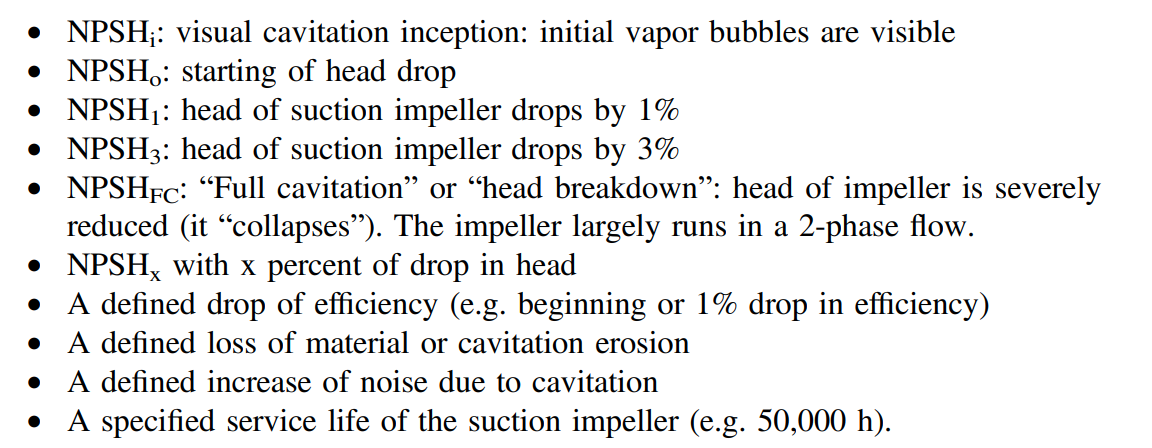

The following fundamental formula will be used for NPSHr:
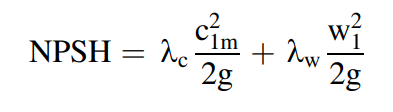

In [77]:
import math
from CoolProp.CoolProp import PropsSI 
import numpy as np
def runCav(p_out,mdot,rpm):
    """
    Calculate cavitation and performance parameters for a pump as a function of inlet pressure. Assumes working fluid is LOx.This one uses Gulich's NPSHr formula for inlet fia

    Parameters
    ----------
    p_out : float
        Outlet pressure in psi.
    mdot : float
        Mass flow rate in kg/s.
    rpm : float
        Rotational speed in rpm.
    Returns
    -------
    P : list
        List of pressures.
    NPSHa : list
        List of available net positive suction heads.
    NPSHr : list
        List of required net positive suction heads.
    inletPressure : list
        List of inlet pressures.
    """
    p_out_pa = p_out * 6894.75729
    inletPressure = []
    P = []
    NPSHa = []
    NPSHri = []
    NPSHr3 = []
    u1 = []
    u13 = []
    lam_c = 1.1 
    lam_w3 = .3 #conservative for impellers based on gulich's p.338-339
    lam_wi = 1.5 #conservative for impellers based on gulich's p.338-339
    p_v = PropsSI('P','T',90,'Q',0,'oxygen') #vapor pressure of LOx at 90K in Pa
    d_n = 0.02 #assumed hub diameter in m
    for p_in in np.arange(0, p_out_pa*.75, 6894.75729):
        inletPressure.append(p_in/6894.75729)
        deltap = p_out_pa - p_in
        H = deltap / (9.81*1141)
        Q = mdot / (1141)
        
        # find efficiency -> power
        if Q <= 1:
            a = 1 
        elif Q > 1:
            a = .5
        n_q = rpm * Q**.5 / (H**.75)
        m = 0.1 * a * ((1/Q)**(.15)) * ((45/n_q)**(0.06))
        eta = 1 - (0.095*((1/Q)**m)) - (.3*((.35 - math.log10(n_q/23))**2)*((1/Q)**(.05)))
        P.append(1141*9.81*H*Q/eta)
        
        
        # Finding NPSHa
        NPSHa.append((p_in - p_v) / (1141*9.81))
        
        
        # Finding NPSHrs (first find v triangles)
        psi = 1.33 * math.exp(-.77 * n_q / 100)
        d_2 = 84.6/rpm * ((H/psi)**.5)
        d_1 = (d_n**2 + 10.6 * (Q/rpm)**(2/3) * ((lam_c+lam_wi)/lam_wi)**(1/3))**.5
        u1c = math.pi * d_1 * rpm / 60
        c_1m = Q * 4 / (math.pi*(d_1**2-d_n**2))
        w_1 = (u1c**2 + c_1m**2)**.5
        u1.append(u1c)
        NPSHri.append(lam_c*c_1m**2/(2*9.81) + lam_wi*w_1**2/(2*9.81))
        
        
        d_13 = (d_n**2 + 10.6 * (Q/rpm)**(2/3) * ((lam_c+lam_w3)/lam_w3)**(1/3))**.5
        u1c3 = math.pi * d_13 * rpm / 60
        c_1m = Q * 4 / (math.pi*(d_13**2-d_n**2))
        w_1 = (u1c3**2 + c_1m**2)**.5
        u13.append(u1c3)
        NPSHr3.append(lam_c*c_1m**2/(2*9.81) + lam_w3*w_1**2/(2*9.81))
    return P, NPSHa, NPSHri, NPSHr3, inletPressure, u1, u13

def runCav2(p_out,mdot,rpm):
    """
    Calculate cavitation and performance parameters for a pump as a function of inlet pressure. Assumes working fluid is LOx. This one uses gulich's minimum relative velocity formula for inlet diameter.

    Parameters
    ----------
    p_out : float
        Outlet pressure in psi.
    mdot : float
        Mass flow rate in kg/s.
    rpm : float
        Rotational speed in rpm.
    Returns
    -------
    P : list
        List of pressures.
    NPSHa : list
        List of available net positive suction heads.
    NPSHr : list
        List of required net positive suction heads.
    inletPressure : list
        List of inlet pressures.
    """
    p_out_pa = p_out * 6894.75729
    inletPressure = []
    P = []
    NPSHa = []
    NPSHri = []
    NPSHr3 = []
    u1 = []
    u13 = []
    lam_c = 1.1 
    lam_w3 = .3 #conservative for impellers based on gulich's p.338-339
    lam_wi = 1.5 #conservative for impellers based on gulich's p.338-339
    p_v = PropsSI('P','T',90,'Q',0,'oxygen') #vapor pressure of LOx at 90K in Pa
    d_n = 0.02 #assumed hub diameter in m
    for p_in in np.arange(0, p_out_pa*.75, 6894.75729):
        inletPressure.append(p_in/6894.75729)
        deltap = p_out_pa - p_in
        H = deltap / (9.81*1141)
        Q = mdot / (1141)
        
        # find efficiency -> power
        if Q <= 1:
            a = 1 
        elif Q > 1:
            a = .5
        n_q = rpm * Q**.5 / (H**.75)
        m = 0.1 * a * ((1/Q)**(.15)) * ((45/n_q)**(0.06))
        eta = 1 - (0.095*((1/Q)**m)) - (.3*((.35 - math.log10(n_q/23))**2)*((1/Q)**(.05)))
        P.append(1141*9.81*H*Q/eta)
        
        
        # Finding NPSHa
        NPSHa.append((p_in - p_v) / (1141*9.81))
        
        
        # Finding NPSHrs (first find v triangles)
        psi = 1.33 * math.exp(-.77 * n_q / 100)
        d_2 = 84.6/rpm * ((H/psi)**.5)
        d_1 = d_2*1.15*((d_n/d_2)**2 + (1.48*10**-3)*psi*(n_q**1.33) / (.95**.67))**.5
        u1c = math.pi * d_1 * rpm / 60
        c_1m = Q * 4 / (math.pi*(d_1**2-d_n**2))
        w_1 = (u1c**2 + c_1m**2)**.5
        u1.append(u1c)
        NPSHri.append(lam_c*c_1m**2/(2*9.81) + lam_wi*w_1**2/(2*9.81))
        NPSHr3.append(lam_c*c_1m**2/(2*9.81) + lam_w3*w_1**2/(2*9.81))
    return P, NPSHa, NPSHri, NPSHr3, inletPressure, u1, u13

Simplifications made:
1. assuming fd1 = 1.15 for eq 7.1.4
2. assuming no swirl velocity

The first version uses the methodology to size for cavitation based, while the second is for minimum relative velocity at the inlet


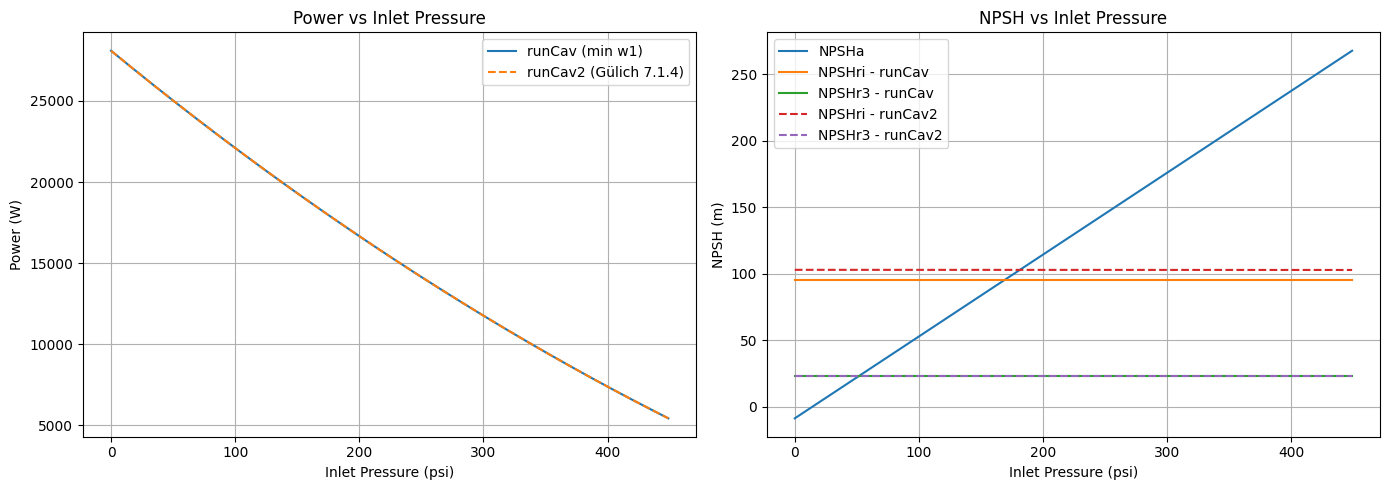

23.258044671893344


In [81]:
p_out = 600
mdot = 3.75
rpm = 22000

P1, NPSHa1, NPSHri1, NPSHr3_1, inletPressure1, u1_1, u13_1 = runCav(p_out, mdot, rpm)
P2, NPSHa2, NPSHri2, NPSHr3_2, inletPressure2, u1_2, u13_2 = runCav2(p_out, mdot, rpm)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Power comparison
ax1.plot(inletPressure1, P1, label='runCav (min w1)')
ax1.plot(inletPressure2, P2, label='runCav2 (Gülich 7.1.4)', linestyle='--')
ax1.set_xlabel('Inlet Pressure (psi)')
ax1.set_ylabel('Power (W)')
ax1.set_title('Power vs Inlet Pressure')
ax1.legend()
ax1.grid(True)

# NPSH comparison
ax2.plot(inletPressure1, NPSHa1, label='NPSHa')
ax2.plot(inletPressure1, NPSHri1, label='NPSHri - runCav')
ax2.plot(inletPressure1, NPSHr3_1, label='NPSHr3 - runCav')
ax2.plot(inletPressure2, NPSHri2, label='NPSHri - runCav2', linestyle='--')
ax2.plot(inletPressure2, NPSHr3_2, label='NPSHr3 - runCav2', linestyle='--')
ax2.set_xlabel('Inlet Pressure (psi)')
ax2.set_ylabel('NPSH (m)')
ax2.set_title('NPSH vs Inlet Pressure')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(NPSHr3_1[0])

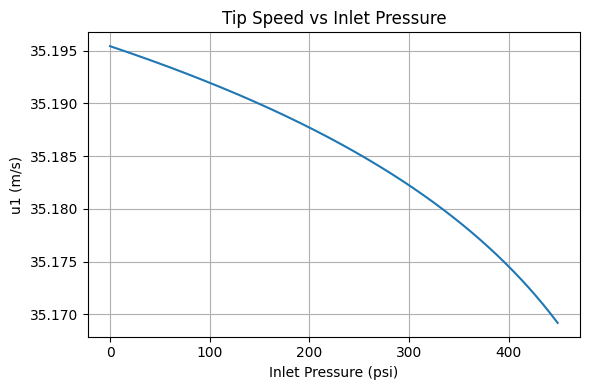

In [79]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(inletPressure, u1)
ax.set_xlabel('Inlet Pressure (psi)')
ax.set_ylabel('u1 (m/s)')
ax.set_title('Tip Speed vs Inlet Pressure')
ax.grid(True)

plt.tight_layout()
plt.show()

what you can see is that using the methodology from gulich's to design for a specific